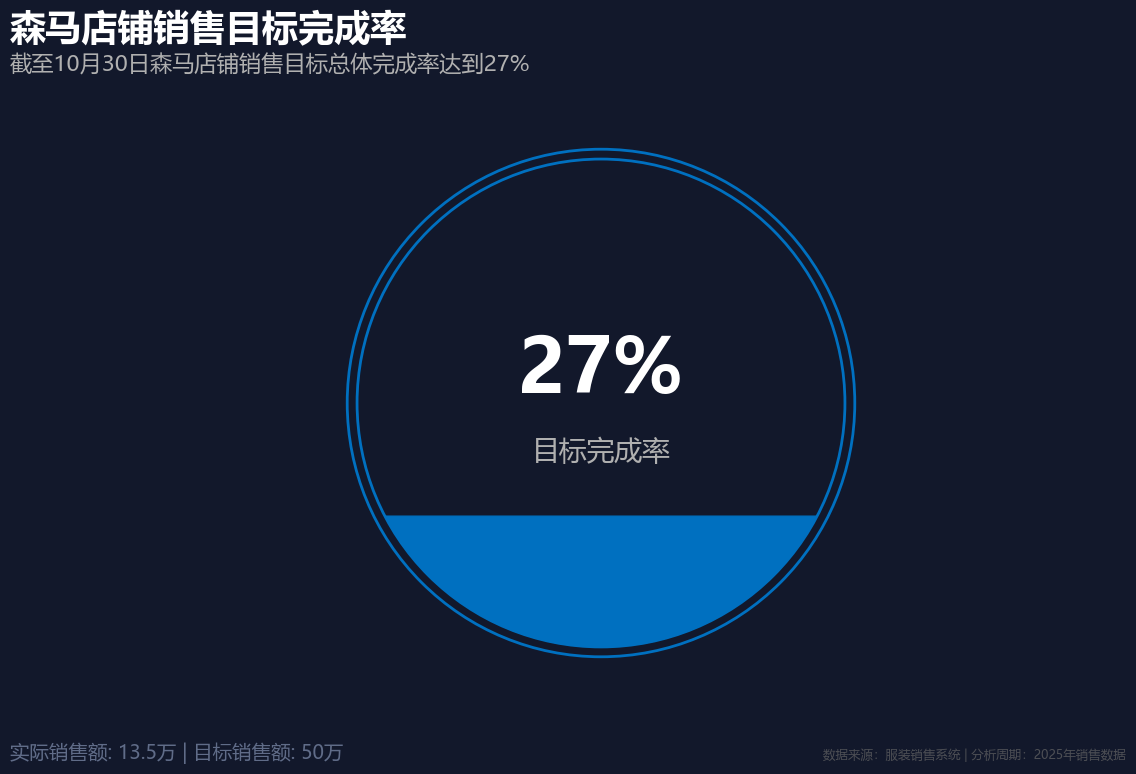

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Circle

# 设置中文字体支持
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'KaiTi']  # 支持中文
plt.rcParams['axes.unicode_minus'] = False  # 正确显示负号

try:
    # 读取订单数据
    df_orders = pd.read_csv('../../erp_order.csv', encoding='utf-8-sig')
    
    # 检查必要列是否存在
    if '店铺名称' not in df_orders.columns or '已付金额' not in df_orders.columns or '下单时间' not in df_orders.columns:
        raise ValueError("订单数据中缺少必要列: '店铺名称'、'已付金额' 或 '下单时间'")
    
    # 过滤出包含"森马"的店铺
    senma_orders = df_orders[df_orders['店铺名称'].str.contains('森马', na=False)]
    
    if senma_orders.empty:
        raise ValueError("未找到包含'森马'的店铺数据")
    
    # 计算实际销售额（已付金额总和）
    actual_sales = senma_orders['已付金额'].sum()
    
    # 设定年度销售目标 (50万人民币)
    target_sales = 500000.0
    
    # 计算完成率
    completion_rate = min(actual_sales / target_sales * 100, 100)
    
    # 获取数据覆盖的最新日期
    latest_date = pd.to_datetime(senma_orders['下单时间']).max().strftime('%m月%d日')
    
    # 创建画布
    fig, ax = plt.subplots(figsize=(12, 8), facecolor='#12182B')
    ax.set_facecolor('#12182B')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect('equal', adjustable='box')
    ax.axis('off')
    
    # 定义圆的参数
    center = (0.5, 0.5)
    radius = 0.4
    
    # 绘制外层圆环
    outer_circle = Circle(center, radius * 1.03, 
                          fill=False, 
                          edgecolor='#0070c0', 
                          linewidth=2, 
                          alpha=1)
    ax.add_patch(outer_circle)

    inner_circle = Circle(center, radius * 0.99, 
                          fill=False, 
                          edgecolor='#0070c0', 
                          linewidth=2, 
                          alpha=1)
    ax.add_patch(inner_circle)
    
    # 计算水位高度
    water_level = center[1] - radius * (1 - 2 * (completion_rate / 100))
    
    # 创建水波效果
    theta = np.linspace(0, 2*np.pi, 500)
    x = center[0] + (radius * 0.99) * np.cos(theta)
    y = center[1] + (radius * 0.99) * np.sin(theta)
    
    # 找到圆内低于水位的点
    water_mask = y <= water_level
    
    # 计算水位线
    water_line_x = x[water_mask]
    water_line_y = np.full_like(water_line_x, water_level)

    # 创建水区域
    water_color = '#0070c0'
    
    # 创建水区域多边形
    water_points = np.column_stack((water_line_x, water_line_y))
    circle_boundary = np.column_stack((x[water_mask], y[water_mask]))
    
    # 闭合多边形
    water_polygon = np.vstack([water_points, circle_boundary[::-1]])
    
    # 绘制水区域
    ax.fill(water_polygon[:, 0], water_polygon[:, 1], 
            color=water_color,
            alpha=1)
    
    # 添加中心文本
    ax.text(center[0], center[1] + 0.05, f"{completion_rate:.0f}%",
            va='center', ha='center', fontsize=55, color='white', fontweight='bold')
    ax.text(center[0], center[1] - 0.08, "目标完成率",
            va='center', ha='center', fontsize=20, color='#B0B0B0')
    
    # 添加标题和说明
    plt.figtext(0.02, 0.95, "森马店铺销售目标完成率",
                ha='left', fontsize=26, color='white', fontweight='bold')
    plt.figtext(0.02, 0.91, f"截至{latest_date}森马店铺销售目标总体完成率达到{completion_rate:.0f}%",
                ha='left', fontsize=16, color='#B0B0B0')
    
    # 添加销售额说明
    actual_formatted = f"{actual_sales/10000:.1f}万"
    target_formatted = f"{target_sales/10000:.0f}万"
    plt.figtext(0.02, 0.05,
                f"实际销售额: {actual_formatted} | 目标销售额: {target_formatted}",
                ha='left', fontsize=14, color='#606C88')
    
    # 添加数据来源说明
    plt.figtext(0.95, 0.05,
                '数据来源：服装销售系统 | 分析周期：2025年销售数据',
                ha='right', fontsize=9, color='#666666', alpha=0.7)
    
    # 保存图表
    plt.savefig('森马店铺销售目标完成率.png', dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
    
    # 显示图表
    plt.show()

except Exception as e:
    print(f"图表生成失败: {str(e)}")
    raise

# 分析

- **目标完成率**：
  截至10月30日，森马店铺的销售目标总体完成率为27%。这一比率表明，店铺在实现年度销售目标方面还有较大的提升空间。

- **实际销售额**：
  实际销售额为13.5万元，相对于设定的目标销售额50万元，仅完成了27%。这显示出店铺在销售执行方面面临一定的挑战。

- **未完成部分**：
  剩余的73%（即约36.5万元）需要在未来的时间内完成，以实现全年销售目标。


# 结论

从销售目标完成率的分析来看，森马店铺在2025年的销售表现尚未达到预期，完成率仅为27%。这可能归因于市场竞争激烈、产品需求不匹配或营销策略不够有效。为了提高销售目标的完成率，店铺需要采取更积极的措施。